# Module 11 Lab: Real-Time Object Tracking and Zone-Based Analytics

**Student Name:** Ahmet Burak Solak  
**Student Number:** W216974196  
**Course:** ITAI1378  
**Submission File:** L11_Solak_Ahmet_ITAI1378.ipynb

This notebook is my finished simple class Lab 11 work for Ahmet Burak Solak.
I used basic YOLO to follow people in a public video, and I counted line crossings and people inside a box zone.
I also answered the main thinking questions about tracking problems, zone analytics, and basic privacy.


## Learning Objectives

By the end, I can clearly explain object detection and object tracking today.
I can build a simple YOLO tracking pipeline here.
I can make line and box zones for useful analytics work.
I can talk about common problems and basic ethics in this kind of system.


## 1. Setup and Installation

I install the needed packages for YOLO, OpenCV, requests, and the small tracker helper.


In [1]:
%pip install ultralytics opencv-python requests lap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Now I import the main libraries and check the local device.


In [2]:
from pathlib import Path

from ultralytics import YOLO
import cv2
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✓ Installation complete")
print(f"Using device: {DEVICE.upper()}")


✓ Installation complete
Using device: CPU


## 2. Understanding Object Tracking

Object detection finds visible objects in one image or video frame.
Object tracking follows the same moving object across many video frames.
Tracking is useful for stores, traffic, and security because it gives clear object IDs over real time.


## Section 1: Understanding Object Tracking

Detection tells what object is in a single frame and where it is now.
Tracking connects detections between nearby frames, so the same person can keep one stable ID.
IOU means Intersection over Union in simple words.
It compares two boxes by looking at the shared overlap area and the total area together.
A tracker uses this normal kind of box matching, motion, and confidence to keep IDs stable in video.


## Part 1: Coded Demonstration

I track moving people in a sample public video and count when they cross a horizontal line.


In [3]:
# 1. Load the YOLO model
model = YOLO('yolov8n.pt')

In [4]:
# 2. Download a reliable public video to analyze.
# The original lab URL returned 404 during validation, so this uses OpenCV's public sample video.
video_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi'
video_path = 'vtest.avi'

if not Path(video_path).exists() or Path(video_path).stat().st_size == 0:
    response = requests.get(video_url, stream=True, timeout=30)
    response.raise_for_status()
    with open(video_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print(f"Video ready: {video_path} ({Path(video_path).stat().st_size / (1024 * 1024):.2f} MB)")


Video ready: vtest.avi (7.75 MB)


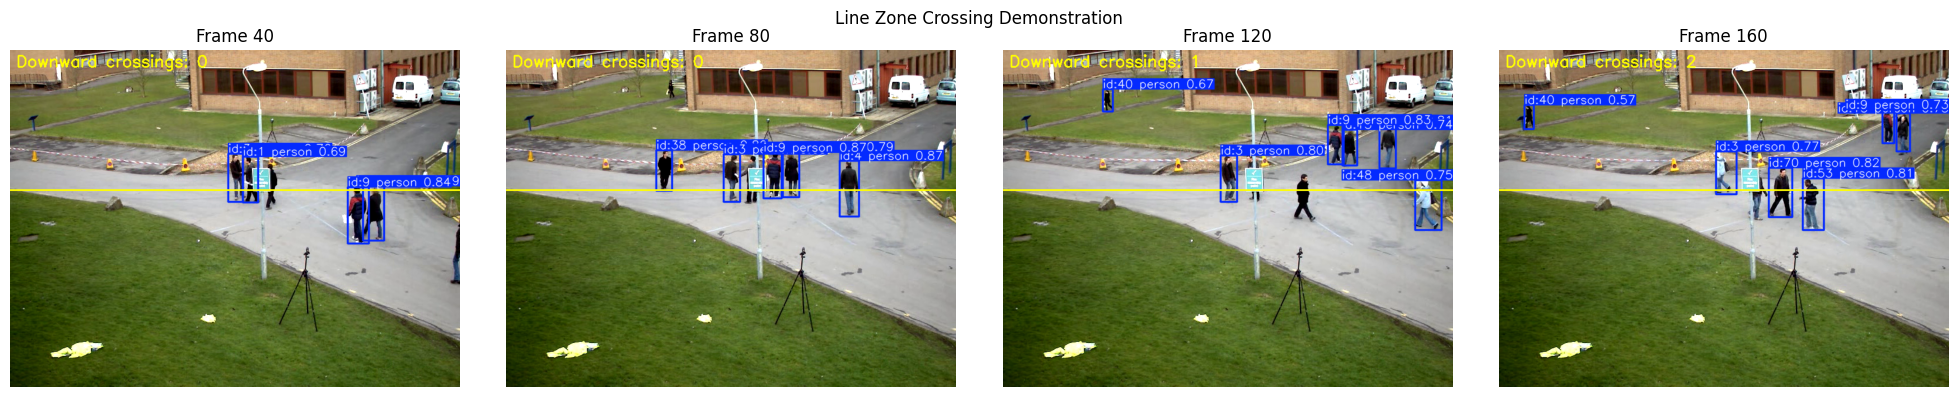

{'frames_read': 160, 'line_y': 240, 'unique_objects_crossed_downward': 2, 'crossed_track_ids': [3, 32]}


{'frames_read': 160,
 'line_y': 240,
 'unique_objects_crossed_downward': 2,
 'crossed_track_ids': [3, 32]}

In [5]:
# 3. Create the Tracking and Zone Analytics Agent

def display_sample_frames(sample_frames, title):
    if not sample_frames:
        print("No sample frames were captured for display.")
        return

    fig, axes = plt.subplots(1, len(sample_frames), figsize=(5 * len(sample_frames), 4))
    if len(sample_frames) == 1:
        axes = [axes]

    for ax, (frame_number, image) in zip(axes, sample_frames):
        ax.imshow(image)
        ax.set_title(f"Frame {frame_number}")
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def tracking_agent(video_path, zone_y=240, max_frames=160, frame_stride=2, display_every=40):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video file: {video_path}")

    crossed_objects = set()
    previous_centers = {}
    sample_frames = []
    processed_frames = 0

    while cap.isOpened() and processed_frames < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        processed_frames += 1
        if processed_frames % frame_stride != 0:
            continue

        results = model.track(
            frame,
            persist=True,
            conf=0.25,
            classes=[0],  # class 0 is person in the COCO label set
            verbose=False,
            device=DEVICE,
        )

        annotated_frame = results[0].plot()
        cv2.line(annotated_frame, (0, zone_y), (frame.shape[1], zone_y), (0, 255, 255), 2)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                center_y = float((box[1] + box[3]) / 2)
                previous_y = previous_centers.get(track_id)

                if previous_y is not None and previous_y < zone_y <= center_y:
                    crossed_objects.add(track_id)

                previous_centers[track_id] = center_y

        cv2.putText(
            annotated_frame,
            f"Downward crossings: {len(crossed_objects)}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 255),
            2,
        )

        if processed_frames % display_every == 0:
            rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
            sample_frames.append((processed_frames, rgb_frame))

    cap.release()
    display_sample_frames(sample_frames, "Line Zone Crossing Demonstration")

    summary = {
        "frames_read": processed_frames,
        "line_y": zone_y,
        "unique_objects_crossed_downward": len(crossed_objects),
        "crossed_track_ids": sorted(crossed_objects),
    }
    print(summary)
    return summary


# Run the agent
line_summary = tracking_agent(video_path)
line_summary


## Part 2: Student Challenge

I make a green rectangular zone and count how many tracked people are inside it in each sampled video frame.


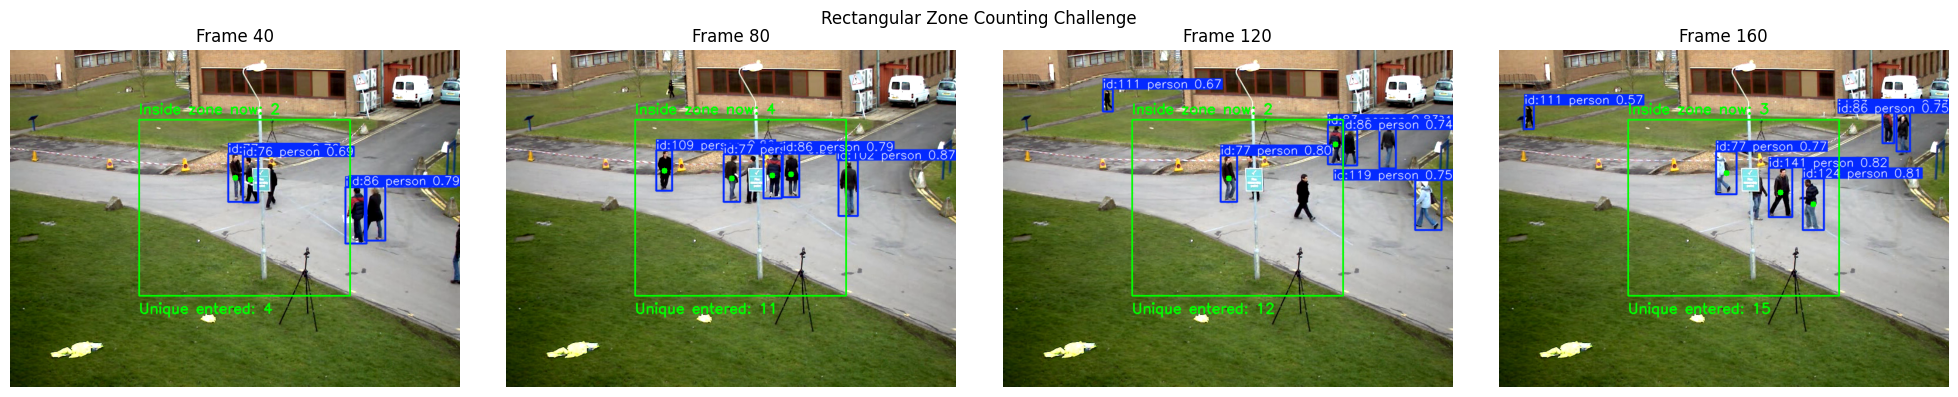

{'frames_read': 160, 'zone': [220, 120, 580, 420], 'objects_inside_last_sampled_frame': 3, 'peak_objects_inside_zone': 5, 'unique_track_ids_seen_in_zone': 15}


{'frames_read': 160,
 'zone': [220, 120, 580, 420],
 'objects_inside_last_sampled_frame': 3,
 'peak_objects_inside_zone': 5,
 'unique_track_ids_seen_in_zone': 15}

In [6]:
# Student Challenge: Rectangular Zone Analytics

# 1. Define the rectangular zone as [x1, y1, x2, y2].
# This zone covers the central walkway area in the OpenCV sample video.
zone = [220, 120, 580, 420]


def zone_counting_agent(video_path, zone, max_frames=160, frame_stride=2, display_every=40):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video file: {video_path}")

    x1, y1, x2, y2 = zone
    unique_ids_seen_in_zone = set()
    peak_count = 0
    last_count = 0
    sample_frames = []
    processed_frames = 0

    while cap.isOpened() and processed_frames < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        processed_frames += 1
        if processed_frames % frame_stride != 0:
            continue

        results = model.track(
            frame,
            persist=True,
            conf=0.25,
            classes=[0],
            verbose=False,
            device=DEVICE,
        )

        annotated_frame = results[0].plot()
        current_count = 0

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                center_x = float((box[0] + box[2]) / 2)
                center_y = float((box[1] + box[3]) / 2)
                inside_zone = x1 <= center_x <= x2 and y1 <= center_y <= y2

                if inside_zone:
                    current_count += 1
                    unique_ids_seen_in_zone.add(track_id)
                    cv2.circle(annotated_frame, (int(center_x), int(center_y)), 5, (0, 255, 0), -1)

        peak_count = max(peak_count, current_count)
        last_count = current_count

        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            annotated_frame,
            f"Inside zone now: {current_count}",
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )
        cv2.putText(
            annotated_frame,
            f"Unique entered: {len(unique_ids_seen_in_zone)}",
            (x1, min(frame.shape[0] - 20, y2 + 30)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )

        if processed_frames % display_every == 0:
            rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
            sample_frames.append((processed_frames, rgb_frame))

    cap.release()
    display_sample_frames(sample_frames, "Rectangular Zone Counting Challenge")

    summary = {
        "frames_read": processed_frames,
        "zone": zone,
        "objects_inside_last_sampled_frame": last_count,
        "peak_objects_inside_zone": peak_count,
        "unique_track_ids_seen_in_zone": len(unique_ids_seen_in_zone),
    }
    print(summary)
    return summary


# 3. Run the new rectangular-zone analytics agent.
zone_summary = zone_counting_agent(video_path, zone)
zone_summary


## Reflective Questions

These answers explain the clear difference between prediction and tracking, the one-count rule, one real use case, and common tracking challenges.


## Reflective Questions: Completed Answers

1. I think `model.predict()` only detects basic things in one video frame.
`model.track()` also detects simple things, but it keeps an ID for the same object over real time.
That ID is why tracking can count clear movement and not only many boxes.

2. The code used a small set called `crossed_objects` in memory.
When a track ID crossed the yellow line, the ID went into the saved set.
After that, the same ID was not counted again later in the video.
This matters because a video has many frames, and one person can stay below the line for a long busy time.

3. One real use is a small busy retail store entrance.
I would put a clear line at the front door to count entries and exits.
I would also put a simple box zone near a front product display to see how many shoppers stop there.
This can help with daily staffing and useful display planning.

4. Tracking is hard when people overlap, hide behind large things, or move very fast.
The tracker can lose an old ID and then give the person a new ID again.
Bad lighting, blurry motion, moving cameras, and false detections can also make the final results very bad.

## Section 2: Tracker Parameter Observations

I filtered the model to the person class because the sample video mainly shows everyday moving people.
The confidence value was not too low and not too high for this work.
If it is too low, weak detections can make many bad false tracks.
If it is too high, partly hidden people can be missed in busy frames.
Processing every second frame made the local notebook faster, and the motion was still clear enough for class.

## Section 3: Zone Analytics Results

The line zone counted a person only when the same center moved from above the yellow line to below it.
This is better than only checking if the whole box is already below the line.
The box zone checked if the center point was inside the small green rectangle.
It showed the current inside count and the total number of unique IDs that entered the same zone.

## Section 4: Critical Analysis of Performance and Limitations

The main limit is that tracking mostly depends on good detection.
If YOLO misses a person for several frames, the tracker may quickly lose the original ID.
Occlusion is a big problem because two close people can overlap and look like one single object.
Zone analytics also depends on fixed camera position and careful zone placement.
A bad line or box can count nearby people at the wrong time or in the wrong place again.
For ethics, this kind of system should use only safe aggregate counts and avoid personal identification.
People should know when cameras are used, and stored data should be limited in time.

## Section 5: Synthesis and Final Reflection

For traffic management, I would track moving vehicles at a busy intersection.
I would put line zones at lane entrances and exits on each side.
I would put a box zone inside the main intersection to see heavy congestion.
The system would measure vehicle counts, direction, queue length, and waiting time in the intersection.
I would test it in day, night, rain, and real heavy traffic conditions.
I would compare automatic counts with manual counts from small local sample clips.
This matters because the video can maybe look correct while the final numbers are still wrong.


## Submission Instructions

The finished notebook is saved with the required class course file name today.
